In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [53]:
def getCSV(csv):
    dfl = pd.read_csv(csv)
    return dfl
df = getCSV(r'C:\Users\Tom\OneDrive\Documents\APROJECTS\NationalitySector.csv') 
df['NACE Rev 2 Economic Sector'] = df['NACE Rev 2 Economic Sector'].apply(lambda x: x.split("(")[0].strip())
print(list(set(df["NACE Rev 2 Economic Sector"])))

['Human health and social work activities', 'Financial, insurance and real estate activities', 'Administrative and support service activities', 'Wholesale and retail trade; repair of motor vehicles and motorcycles', 'Professional, scientific and technical activities', 'Education', 'Arts, entertainment, recreation and other service activities', 'Construction', 'Accommodation and food service activities', 'Industry', 'Transportation and storage', 'Public administration and defence; compulsory social security', 'Information and communication']


In [79]:
sector="Construction"
label="Mean Weekly Earnings"
filtered_df = df[df['NACE Rev 2 Economic Sector']==sector]
filtered_df = filtered_df[filtered_df["Statistic Label"]==label]
filtered_df = filtered_df[filtered_df["Nationality"]!="All nationalities"]
print(filtered_df)

          Statistic Label  Year NACE Rev 2 Economic Sector  \
12   Mean Weekly Earnings  2023               Construction   
13   Mean Weekly Earnings  2023               Construction   
14   Mean Weekly Earnings  2023               Construction   
15   Mean Weekly Earnings  2023               Construction   
16   Mean Weekly Earnings  2023               Construction   
17   Mean Weekly Earnings  2023               Construction   
18   Mean Weekly Earnings  2023               Construction   
19   Mean Weekly Earnings  2023               Construction   
20   Mean Weekly Earnings  2023               Construction   
21   Mean Weekly Earnings  2023               Construction   
22   Mean Weekly Earnings  2023               Construction   
168  Mean Weekly Earnings  2024               Construction   
169  Mean Weekly Earnings  2024               Construction   
170  Mean Weekly Earnings  2024               Construction   
171  Mean Weekly Earnings  2024               Construction   
172  Mea

In [80]:
def changeNames(name):
    switch = {
        "United Kingdom of Great Britain and Northern Ireland (the)": "UK",
        "Other countries (2)": "Other"
    }
    
    if name not in switch:
        return name 
    else:
        return switch[name]
filtered_df['Nationality'] = filtered_df['Nationality'].apply(changeNames)

In [81]:
two_four_df = filtered_df[filtered_df["Year"]==2024]
two_three_df = filtered_df[filtered_df["Year"]==2023]
merged = pd.merge(two_three_df, two_four_df, on="Nationality")

In [82]:
print(merged)

       Statistic Label_x  Year_x NACE Rev 2 Economic Sector_x Nationality  \
0   Mean Weekly Earnings    2023                 Construction     Ireland   
1   Mean Weekly Earnings    2023                 Construction      Poland   
2   Mean Weekly Earnings    2023                 Construction          UK   
3   Mean Weekly Earnings    2023                 Construction       India   
4   Mean Weekly Earnings    2023                 Construction     Romania   
5   Mean Weekly Earnings    2023                 Construction      Brazil   
6   Mean Weekly Earnings    2023                 Construction   Lithuania   
7   Mean Weekly Earnings    2023                 Construction       Spain   
8   Mean Weekly Earnings    2023                 Construction       Italy   
9   Mean Weekly Earnings    2023                 Construction     Ukraine   
10  Mean Weekly Earnings    2023                 Construction       Other   

   UNIT_x  VALUE_x     Statistic Label_y  Year_y NACE Rev 2 Economic Sector

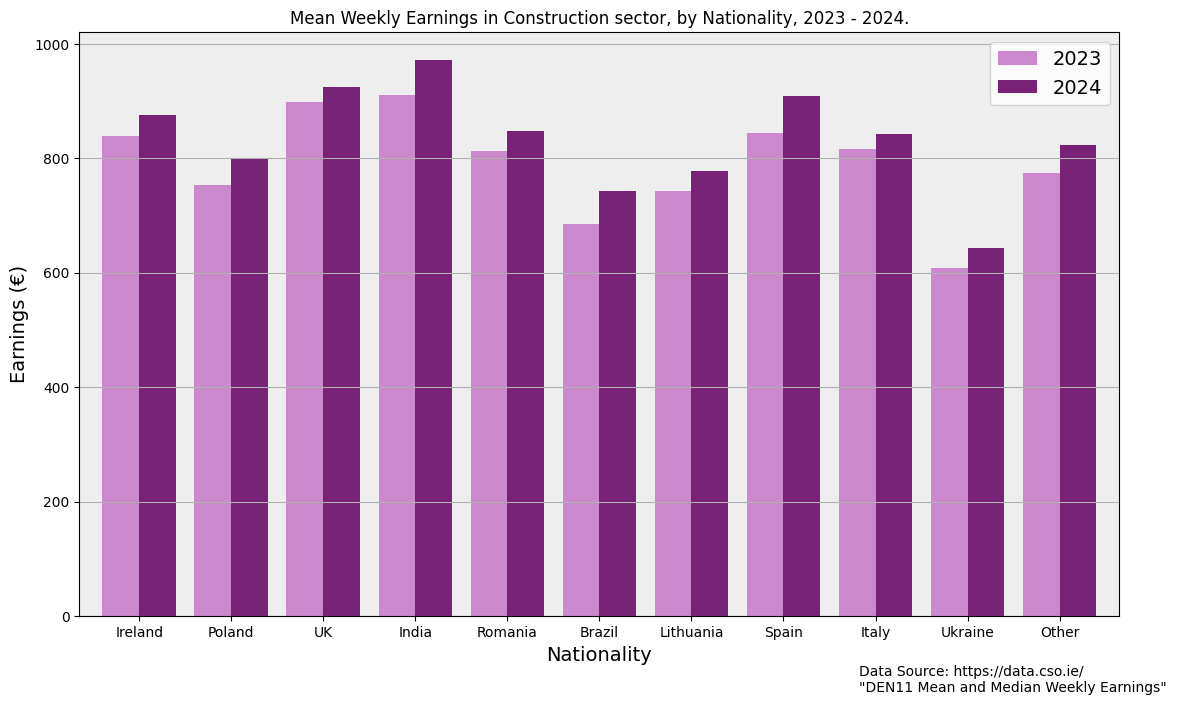

In [83]:
fig, ax = plt.subplots(1, 1, figsize=(13, 8))

merged.plot(kind='bar', x='Nationality', y=['VALUE_x', 'VALUE_y'], color=['#C8C', '#727'], label=["2023", "2024"], width=0.8, ax=ax)

title_string = label+" in "+sector+" sector, by Nationality, 2023 - 2024."

plt.title(title_string)
plt.xlabel('Nationality', fontsize=14)
plt.ylabel('Earnings (€)', fontsize=14)
plt.xticks(rotation=0) 
#ax.set_xlim(200,550)
ax.set_facecolor('#EEEEEE') 
ax.legend(fontsize=14) 
plt.grid(True, axis="y")


plt.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.17)
plt.text(0.75, -0.13, "Data Source: https://data.cso.ie/ \n\"DEN11 Mean and Median Weekly Earnings\"", ha='left', transform=ax.transAxes)

save_fig = 'Nationality'+sector+'.png'
plt.savefig(save_fig)

# Show the plot
plt.show()
